In [1]:
import pickle
from ram.dataset.kinematics import inverse_kinematics

from pathlib import Path

In [2]:
save_dir = Path.cwd() / "data"

In [17]:
mean_reachability_ours, lower_reachability_ours, upper_reachability_ours = pickle.load(
    open(save_dir / "ours" / "reachability.pkl", "rb"))
mean_deviation_ours, lower_deviation_ours, upper_deviation_ours = pickle.load(
    open(save_dir / "ours" / "deviation_loss.pkl", "rb"))
mean_reachability_base, lower_reachability_base, upper_reachability_base = pickle.load(
    open(save_dir / "base" / "reachability.pkl", "rb"))
mean_deviation_base, lower_deviation_base, upper_deviation_base = pickle.load(
    open(save_dir / "base" / "deviation_loss.pkl", "rb"))
mean_base_runtime, lower_base_runtime, upper_base_runtime = pickle.load(open(save_dir / "base_runtime.pkl", "rb"))
mean_ours_runtime, lower_ours_runtime, upper_ours_runtime = pickle.load(open(save_dir / "ours_runtime.pkl", "rb"))

In [18]:
mean_deviation_ours *= 2
lower_deviation_ours *= 2
upper_deviation_ours *= 2
mean_deviation_base *= 2
lower_deviation_base *= 2
upper_deviation_base *= 2

In [19]:
mean_pose_error_ours, lower_pose_error_ours, upper_pose_error_ours = pickle.load(
    open(save_dir / "ours" / "pose_error.pkl", "rb"))
mean_self_collision_ours, lower_self_collision_ours, upper_self_collision_ours = pickle.load(
    open(save_dir / "ours" / "self_collision.pkl", "rb"))
mean_pose_error_base, lower_pose_error_base, upper_pose_error_base = pickle.load(
    open(save_dir / "base" / "pose_error.pkl", "rb"))
mean_self_collision_base, lower_self_collision_base, upper_self_collision_base = pickle.load(
    open(save_dir / "base" / "self_collision.pkl", "rb"))

In [35]:
1-  mean_pose_error_base[-1] / mean_pose_error_base[0]

np.float32(0.2299335)

In [33]:
1- mean_pose_error_ours[-1] / mean_pose_error_ours[0]

np.float32(0.53619385)

In [34]:
mean_self_collision_base[-1] * 10, mean_self_collision_base[0] * 10

(np.float64(3.0), np.float64(8.8))

In [28]:
mean_self_collision_ours[-1] / 10, mean_self_collision_ours[0] / 10

(np.float64(0.05500000000000001), np.float64(0.097))

/tmp/ipykernel_1941776/3236992208.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


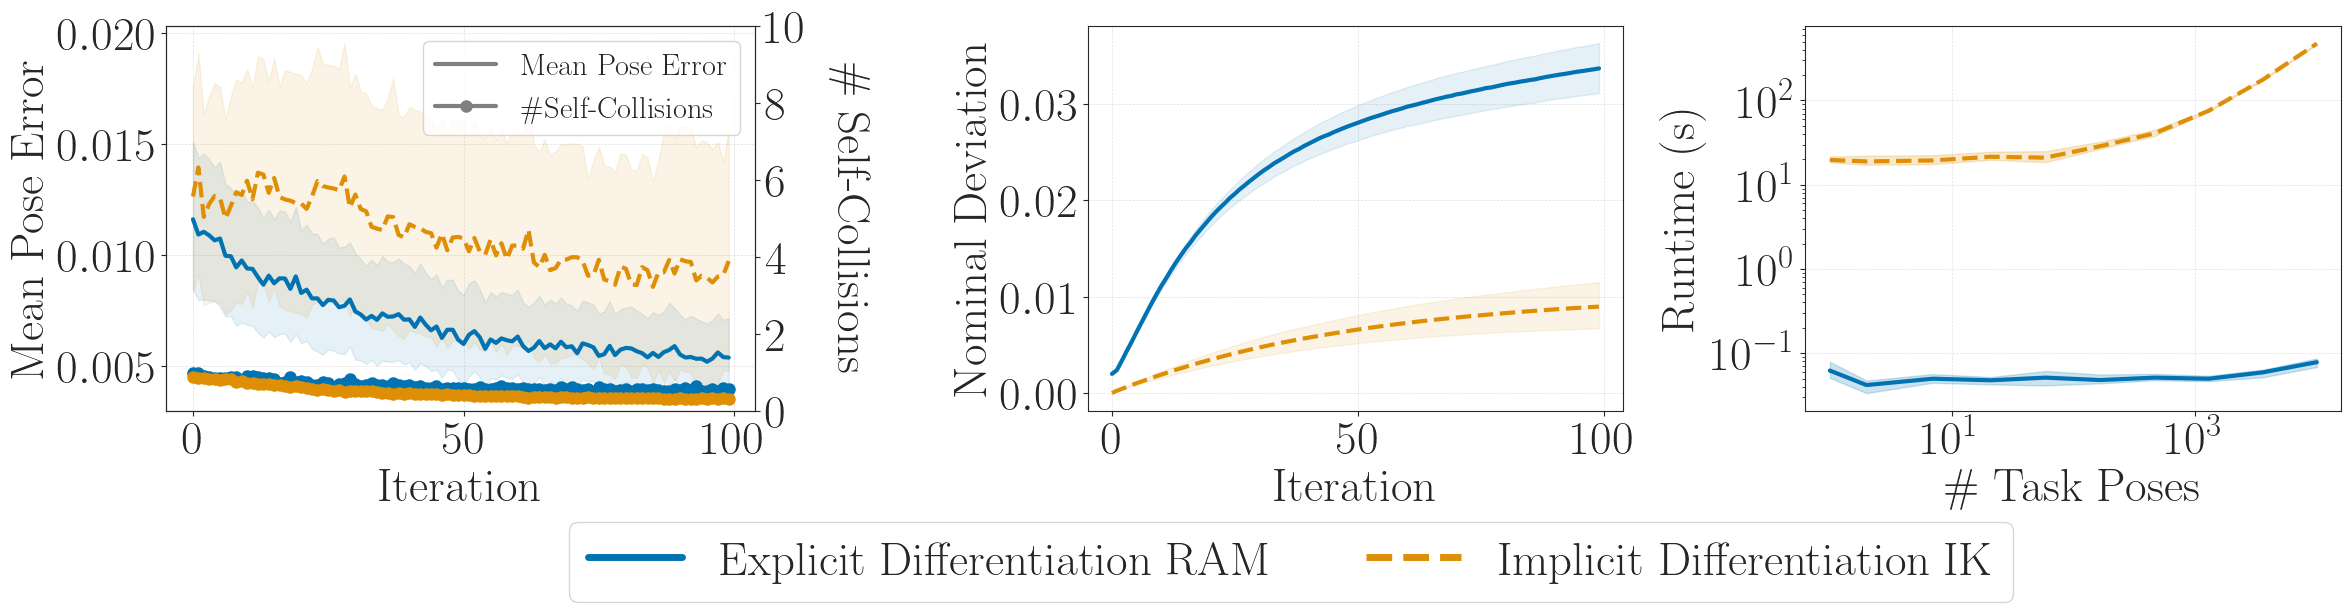

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
import pickle
from matplotlib.lines import Line2D

# --- Style Configuration ---
sns.set_style("ticks")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "text.latex.preamble": r"\usepackage{amsmath}",

    "axes.labelsize": 34,
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "legend.fontsize": 34,
    "axes.titlesize": 34,
    "lines.linewidth": 3,
})

fig = plt.figure(figsize=(30, 5))

# 1. Create a GridSpec for the whole figure.
# We add extra width to the first column to "absorb" the twin axis label.
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1, 1], wspace=0.6)

ax = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
colors = sns.color_palette("colorblind", 4)
x = torch.arange(0, 100)

# ---------------------------------------------------------
# PLOT 1: POSE ERROR & SELF COLLISIONS (TWIN X)
# ---------------------------------------------------------
ax0_twin = ax[0].twinx()

# Pose error — no marker (left axis)
ax[0].plot(x, mean_pose_error_ours, color=colors[0], linestyle='-')
ax[0].plot(x, mean_pose_error_base, color=colors[1], linestyle='--')

ax[0].fill_between(x, lower_pose_error_ours, upper_pose_error_ours, color=colors[0], alpha=0.1)
ax[0].fill_between(x, lower_pose_error_base, upper_pose_error_base, color=colors[1], alpha=0.1)
ax[0].set_ylabel(r"$\text{Mean Pose Error}$")
#ax[0].set_yscale("log")

# Self collisions — with marker (right axis)
ax0_twin.plot(x, mean_self_collision_ours, color=colors[0], linestyle='-',
              marker='o', markevery=1, markersize=8)
ax0_twin.plot(x, mean_self_collision_base, color=colors[1], linestyle='--',
              marker='o', markevery=1, markersize=8)
ax0_twin.set_ylabel(r"$\text{\# Self-Collisions}$", rotation=270, labelpad=45)
ax0_twin.set_ylim([0, 10])
ax0_twin.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
ax[0].set_xlabel(r"$\text{Iteration}$")

# Style Legend for Plot 1
style_elements_p1 = [
    Line2D([0], [0], color='gray', linestyle='-', label=r"$\text{Mean Pose Error}$"),
    Line2D([0], [0], color='gray', linestyle='-', marker='o', markersize=8,
           label=r"$\# \text{Self-Collisions}$"),
]
ax[0].legend(handles=style_elements_p1, loc='upper right', fontsize=22)

# ---------------------------------------------------------
# PLOT 2: NOMINAL DEVIATION
# ---------------------------------------------------------
ax[1].plot(x, mean_deviation_ours, color=colors[0])
ax[1].fill_between(x, lower_deviation_ours, upper_deviation_ours, color=colors[0], alpha=0.1)
ax[1].plot(x, mean_deviation_base, color=colors[1],linestyle="dashed")
ax[1].fill_between(x, lower_deviation_base, upper_deviation_base, color=colors[1], alpha=0.1)


ax[1].set_ylabel(r"$\text{Nominal Deviation}$")
ax[1].set_xlabel(r"$\text{Iteration}$")

# ---------------------------------------------------------
# PLOT 3: RUNTIME SCALING
# ---------------------------------------------------------
x_runtime = torch.logspace(0, 4, 10).int()
per_iteration = 100
ax[2].plot(x_runtime, mean_ours_runtime / per_iteration, color=colors[0])
ax[2].fill_between(x_runtime, lower_ours_runtime / per_iteration, upper_ours_runtime / per_iteration, color=colors[0],
                   alpha=0.2)
ax[2].plot(x_runtime, mean_base_runtime / per_iteration, color=colors[1], linestyle="dashed")
ax[2].fill_between(x_runtime, lower_base_runtime / per_iteration, upper_base_runtime / per_iteration, color=colors[1],
                   alpha=0.2)


ax[2].set_ylabel(r"$\text{Runtime (s)}$")
ax[2].set_xlabel(r"$\text{\# Task Poses}$")
ax[2].set_yscale("log")
ax[2].set_xscale("log")

# --- CUSTOM UNEVEN SPACING ---
# We force the third plot to move closer to the second plot.
# Bbox: [left, bottom, width, height]
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Shift Plot 3 left by reducing the gap between 2 and 3
# Adjust the 0.05 value to bring them closer or further
ax[2].set_position([pos3.x0 - 0.05, pos3.y0, pos3.width, pos3.height])

# --- Global Polish ---
for i in range(3):
    ax[i].grid(True, linestyle='--', alpha=0.6)

method_elements = [
    Line2D([0], [0], color=colors[0], lw=5, label=r"$\text{Explicit Differentiation RAM}$"),
    Line2D([0], [0], color=colors[1], lw=5, label=r"$\text{Implicit Differentiation IK}$", linestyle="dashed"),
]

fig.legend(
    handles=method_elements,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.32)
)

# Avoid tight_layout() here as it will override our manual set_position calls
plt.savefig("motion_planning.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [72]:
import os
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
import torch

# ── helpers ──────────────────────────────────────────────────────────────────

def get_robust_l_frame(poses, axis_len=0.05):
    """Return L-frame line data and origins for a batch of 4×4 poses."""
    origins = poses[:, :3, 3]
    z_ends  = origins + poses[:, :3, 2] * axis_len
    x_ends  = origins + poses[:, :3, 0] * axis_len

    segments = torch.stack([z_ends, origins, x_ends], dim=1)
    nans     = torch.full((segments.shape[0], 1, 3), float("nan"), device=poses.device)
    line_data = torch.cat([segments, nans], dim=1).reshape(-1, 3).cpu().numpy()
    return line_data, origins.cpu().numpy()


def to_plotly_color(color):
    return f"rgb{tuple((255 * np.array(color)).astype(int).tolist())}"


# ── load data ─────────────────────────────────────────────────────────────────

morph             = pickle.load(open(save_dir / "ours"/ "morph.pkl",             "rb"))
target_trajectory = pickle.load(open(save_dir / "ours"/ "target_trajectory.pkl", "rb"))
trajectory        = pickle.load(open(save_dir/ "ours" / "trajectory.pkl",        "rb"))
last_reachability = pickle.load(open(save_dir/ "ours" / "last_reachability.pkl", "rb"))
base_trajectory   = pickle.load(open(Path(os.getcwd()) / "data" / "base" / "trajectory.pkl",        "rb"))
base_reachability = pickle.load(open(Path(os.getcwd()) / "data" / "base" / "last_reachability.pkl", "rb"))

true_reachability = inverse_kinematics(morph, target_trajectory)[1].cpu() != -1

# ── matplotlib style (for PDF export) ────────────────────────────────────────

sns.set_style("ticks")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "pgf.rcfonts": False,
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage[T1]{fontenc}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage[italic]{mathastext}
    """,
    "font.size": 24,
    "axes.labelsize": 24,
    "legend.fontsize": 20,
    "axes.unicode_minus": False,
})

# ── style config ──────────────────────────────────────────────────────────────

colors  = sns.color_palette("colorblind")
palette = [
    to_plotly_color(colors[0]),  # Target  – solid blue
    to_plotly_color(colors[1]),  # NRM     – dashed orange
    to_plotly_color(colors[4]),  # IK      – dotted pink
]

color_reach   = to_plotly_color(colors[2])  # green
color_unreach = to_plotly_color(colors[3])  # red

# (name, color, dash, line_width)
trajectory_styles = [
    ("Target", palette[0], "solid", 10),
    ("RAM",    palette[1], "dash",  10),
    ("IK",     palette[2], "dash",   10),
]

trajectories = [target_trajectory.cpu(), trajectory.cpu(), base_trajectory.cpu()]
reachability = [true_reachability,       last_reachability, base_reachability]

# ── build figure ──────────────────────────────────────────────────────────────

fig = go.Figure()

# --- legend sentinel traces (define order and appearance) ---
for name, color, dash, lw in trajectory_styles:
    fig.add_trace(go.Scatter3d(
        x=[None], y=[None], z=[None],
        mode="lines",
        line=dict(color=color, width=lw, dash=dash),
        name=name,
    ))

# Reachable / unreachable sentinels with distinct marker symbols
fig.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode="markers",
    marker=dict(color=color_reach,   size=50, symbol="circle"),
    name="Reachable",
))
fig.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode="markers",
    marker=dict(color=color_unreach, size=50, symbol="x"),
    name="Unreachable",
))

# --- actual data traces ---
for (name, color, dash, lw), traj, reach in zip(trajectory_styles, trajectories, reachability):
    path_lines, origins = get_robust_l_frame(traj)

    # Main path
    fig.add_trace(go.Scatter3d(
        x=origins[:, 0], y=origins[:, 1], z=origins[:, 2],
        mode="lines",
        line=dict(color=color, width=lw, dash=dash),
        showlegend=False,
    ))

    # L-frame orientation indicators
    fig.add_trace(go.Scatter3d(
        x=path_lines[:, 0], y=path_lines[:, 1], z=path_lines[:, 2],
        mode="lines",
        line=dict(color=color, width=4),
        opacity=0.6,
        showlegend=False,
    ))

    # Reachable poses
    if torch.any(reach):
        r_lines, r_pts = get_robust_l_frame(traj[reach])
        fig.add_trace(go.Scatter3d(
            x=r_pts[:, 0], y=r_pts[:, 1], z=r_pts[:, 2],
            mode="markers",
            marker=dict(color=color_reach, size=6, symbol="circle", opacity=0.8),
            showlegend=False,
        ))
        fig.add_trace(go.Scatter3d(
            x=r_lines[:, 0], y=r_lines[:, 1], z=r_lines[:, 2],
            mode="lines",
            line=dict(color=color_reach, width=4),
            opacity=0.4,
            showlegend=False,
        ))

    # Unreachable poses
    if torch.any(~reach):
        u_lines, u_pts = get_robust_l_frame(traj[~reach])
        fig.add_trace(go.Scatter3d(
            x=u_pts[:, 0], y=u_pts[:, 1], z=u_pts[:, 2],
            mode="markers",
            marker=dict(color=color_unreach, size=6, symbol="x", opacity=0.8),
            showlegend=False,
        ))
        fig.add_trace(go.Scatter3d(
            x=u_lines[:, 0], y=u_lines[:, 1], z=u_lines[:, 2],
            mode="lines",
            line=dict(color=color_unreach, width=4),
            opacity=0.4,
            showlegend=False,
        ))

# ── layout ────────────────────────────────────────────────────────────────────

axis_common = dict(
    showgrid=True,
    gridcolor="lightgrey",
    gridwidth=8,
    zeroline=True,
    zerolinecolor="black",
    nticks=5,
    backgroundcolor="rgba(0,0,0,0)",
    tickfont=dict(size=18, family="Arial", color="black"),
)

fig.update_layout(
    template="simple_white",
    width=2000,
    height=500,
    scene=dict(
        xaxis=dict(title="<br><br>X", **axis_common),
        yaxis=dict(title="Y",         **axis_common),
        zaxis=dict(title="Z",         **axis_common),
        xaxis_showspikes=False,
        yaxis_showspikes=False,
        zaxis_showspikes=False,
        xaxis_title_font=dict(size=28, family="Arial"),
        yaxis_title_font=dict(size=28, family="Arial"),
        zaxis_title_font=dict(size=28, family="Arial"),
        aspectmode="manual",
        aspectratio=dict(x=1, y=4, z=1),
        camera=dict(
            center=dict(x=0, y=0, z=0),
            eye=dict(x=-2.402934340972093, y=-0.14253797828641002, z=0.4892977953085054),
            projection=dict(type="perspective"),
            up=dict(x=0, y=0, z=1),
        ),
    ),
    legend=dict(
        orientation="h",
        yanchor="top",
        y=0.85,
        xanchor="center",
        x=0.5,
        font=dict(size=36),
        itemsizing="constant",
        bgcolor="rgba(0,0,0,0)",
    ),
    margin=dict(l=0, r=0, b=0, t=0),
)

# ── export & show ─────────────────────────────────────────────────────────────

fig.write_image("motion_planning_qualitative.pdf", width=2000, height=600)

config = {
    "toImageButtonOptions": {
        "format":   "png",
        "filename": "motion_planning_qualitative",
        "height":   500,
        "width":    2000,
        "scale":    4,
    }
}
fig.show(config=config)